<a href="https://colab.research.google.com/github/dmitrijg08/MN/blob/main/%D0%93%D1%83%D1%81%D0%B0%D0%BA_%D0%94_%D0%9E_3_9_%D0%A2%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_%D0%9B%D0%B5%D0%BA%D1%86%D1%96%D1%8F_3_Pandas_EDA_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тренувальний ноутбук до лекції 3
## Аналіз даних у pandas та EDA

**Дисципліна:** Машинне навчання  
**Редакція:** 2026  

Мета ноутбука - відпрацювати основні операції pandas на єдиному навчальному наборі даних: завантаження, первинне обстеження, індексацію, очищення, групування, об’єднання, переформатування та базову візуалізацію.

> Матеріал орієнтований на pandas 3.0+. Якщо у Google Colab встановлена інша версія, більшість прикладів все одно виконуватиметься, але dtype текстових стовпців може відрізнятися.

## 0. Підготовка середовища

Спочатку імпортуємо бібліотеки та перевіримо версію pandas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


## 1. Створення навчального набору даних

Щоб ноутбук був автономним і запускався у Colab без зовнішніх файлів, згенеруємо невеликий набір даних про клієнтів інтернет-магазину. У ньому навмисно є пропуски, дублікати та неакуратні текстові значення.

In [2]:
rng = np.random.default_rng(42)

n = 120
cities = np.array(["Kyiv", "Lviv", "Odesa", "Dnipro", "Kharkiv"])
segments = np.array(["basic", "standard", "premium"])

customers = pd.DataFrame({
    "customer_id": np.arange(1001, 1001 + n),
    "age": rng.integers(18, 70, size=n),
    "city": rng.choice(cities, size=n, p=[0.30, 0.20, 0.18, 0.16, 0.16]),
    "segment": rng.choice(segments, size=n, p=[0.45, 0.40, 0.15]),
    "signup_date": pd.Timestamp("2022-01-01") + pd.to_timedelta(
        rng.integers(0, 1600, size=n), unit="D"
    ),
    "orders": rng.poisson(7, size=n),
    "spend": np.round(rng.gamma(shape=2.3, scale=280, size=n), 2),
    "churn": rng.choice([0, 1], size=n, p=[0.78, 0.22]),
})

# Навмисно додаємо проблеми якості даних
customers.loc[[5, 18, 44], "age"] = np.nan
customers.loc[[9, 27, 78, 101], "spend"] = np.nan
customers.loc[12, "city"] = " kyiv "
customers.loc[31, "city"] = "LVIV"
customers.loc[66, "segment"] = None
customers.loc[88, "spend"] = -150.0

# Додаємо два дублікати рядків
customers = pd.concat([customers, customers.iloc[[3, 15]]], ignore_index=True)

customers.to_csv("customers_eda.csv", index=False)
print("Файл створено: customers_eda.csv")
print("Розмір:", customers.shape)
customers.head()

Файл створено: customers_eda.csv
Розмір: (122, 8)


,customer_id,age,city,segment,signup_date,orders,spend,churn
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0


## 2. Завантаження даних та первинна перевірка

Завантажимо CSV так, як це робиться у реальному проєкті.

In [3]:
df = pd.read_csv(
    "customers_eda.csv",
    parse_dates=["signup_date"],
)

df.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0


In [4]:
df.shape

(122, 8)

In [5]:
df.columns

Index(['customer_id', 'age', 'city', 'segment', 'signup_date', 'orders',
       'spend', 'churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  122 non-null    int64         
 1   age          119 non-null    float64       
 2   city         122 non-null    object        
 3   segment      121 non-null    object        
 4   signup_date  122 non-null    datetime64[ns]
 5   orders       122 non-null    int64         
 6   spend        118 non-null    float64       
 7   churn        122 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 7.8+ KB


In [7]:
df.describe()

,customer_id,age,signup_date,orders,spend,churn
count,122.000000,119.000000,122,122.000000,118.000000,122.000000
mean,1059.672131,44.512605,2024-04-23 11:00:59.016393472,6.959016,672.393814,0.278689
min,1001.000000,18.000000,2022-01-13 00:00:00,1.000000,-150.000000,0.000000
25%,1029.250000,33.000000,2023-05-01 06:00:00,5.000000,341.800000,0.000000
50%,1059.500000,44.000000,2024-05-06 12:00:00,7.000000,621.640000,0.000000
75%,1089.750000,57.000000,2025-03-27 06:00:00,8.000000,901.750000,1.000000
max,1120.000000,68.000000,2026-05-14 00:00:00,14.000000,2046.770000,1.000000
std,35.100668,14.038606,NaN,2.556462,445.379828,0.450203


### Зверніть увагу
- `shape` показує кількість об'єктів та ознак;
- `info()` допомагає побачити типи й пропуски;
- `describe()` дає базову статистику числових ознак;
- у pandas 3.0 текстові стовпці за замовчуванням можуть мати `str` dtype замість старого `object`.

## 3. Series, DataFrame, loc та iloc

In [8]:
# Один стовпець -> Series
spend = df["spend"]
print(type(spend))

# Кілька стовпців -> DataFrame
small = df[["customer_id", "city", "spend"]]
print(type(small))
small.head()

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,customer_id,city,spend
0,1001,Odesa,347.14
1,1002,Lviv,706.18
2,1003,Odesa,1164.91
3,1004,Dnipro,77.99
4,1005,Odesa,574.75


In [9]:
# loc: вибір за мітками / умовами
high_spend = df.loc[df["spend"] > 1000, ["customer_id", "city", "spend"]]
high_spend.head()

,customer_id,city,spend
2,1003,Odesa,1164.91
6,1007,Odesa,1771.49
15,1016,Kyiv,1190.51
19,1020,Dnipro,1632.17
21,1022,Lviv,1162.84


In [10]:
# iloc: вибір за позиціями
df.iloc[:5, :4]

,customer_id,age,city,segment
0,1001,22.0,Odesa,premium
1,1002,58.0,Lviv,premium
2,1003,52.0,Odesa,standard
3,1004,40.0,Dnipro,basic
4,1005,40.0,Odesa,standard


## 4. Фільтрація даних

In [11]:
mask = (
    df["age"].between(25, 45)
    & df["city"].isin(["Kyiv", "Lviv"])
    & df["spend"].notna()
)

selected = df.loc[mask]
selected.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
8,1009,28.0,Kyiv,standard,2026-03-28,5,409.81,1
10,1011,45.0,Kyiv,premium,2025-08-26,8,134.76,0
16,1017,44.0,Kyiv,standard,2023-02-04,5,425.17,0
21,1022,37.0,Lviv,premium,2024-02-04,8,1162.84,0
30,1031,41.0,Kyiv,standard,2025-03-25,4,851.50,0


In [12]:
# query часто зручний для читабельних числових умов
query_result = df.query("orders >= 8 and spend > 700")
query_result.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
13,1014,57.0,Kyiv,standard,2023-09-09,10,902.89,1
15,1016,58.0,Kyiv,basic,2024-10-20,8,1190.51,1
17,1018,24.0,Odesa,premium,2023-03-03,13,930.86,0


## 5. Пропуски, дублікати та базове очищення

In [13]:
missing = pd.DataFrame({
    "count": df.isna().sum(),
    "share": df.isna().mean(),
}).sort_values("share", ascending=False)

missing

,count,share
spend,4,0.032787
age,3,0.024590
segment,1,0.008197
customer_id,0,0.000000
city,0,0.000000
signup_date,0,0.000000
orders,0,0.000000
churn,0,0.000000


In [14]:
print("Повних дублікатів:", df.duplicated().sum())
print("Дублікатів customer_id:", df.duplicated(subset=["customer_id"]).sum())

Повних дублікатів: 2
Дублікатів customer_id: 2


In [15]:
clean = df.drop_duplicates().copy()

# Негативні витрати трактуємо як помилкове значення
clean.loc[clean["spend"] < 0, "spend"] = np.nan

# Очищення тексту
clean["city"] = clean["city"].str.strip().str.title()
clean["segment"] = clean["segment"].fillna("unknown")

print(clean.shape)
print(clean["city"].value_counts(dropna=False))
print(clean["segment"].value_counts(dropna=False))

(120, 8)
city
Kyiv       38
Lviv       28
Odesa      24
Dnipro     16
Kharkiv    14
Name: count, dtype: int64
segment
basic       58
standard    43
premium     18
unknown      1
Name: count, dtype: int64


### Примітка про ML
У цьому навчальному EDA можна показати заповнення пропусків. Але якщо значення для заповнення (медіана, середнє тощо) використовуватиметься моделлю, його слід оцінювати **лише на train**, бажано всередині `Pipeline`.

In [16]:
# Для дослідницького аналізу створимо окремий стовпець
median_age = clean["age"].median()
clean["age_filled"] = clean["age"].fillna(median_age)

print("Медіана age:", median_age)
clean[["age", "age_filled"]].head(10)

Медіана age: 44.0


,age,age_filled
0,22.0,22.0
1,58.0,58.0
2,52.0,52.0
3,40.0,40.0
4,40.0,40.0
5,NaN,44.0
6,22.0,22.0
7,54.0,54.0
8,28.0,28.0
9,22.0,22.0


## 6. Робота з датами та створення ознак

In [17]:
reference_date = pd.Timestamp("2026-09-07")

clean["signup_year"] = clean["signup_date"].dt.year
clean["signup_month"] = clean["signup_date"].dt.month
clean["tenure_days"] = (reference_date - clean["signup_date"]).dt.days
clean["spend_per_order"] = clean["spend"] / clean["orders"].replace(0, np.nan)

clean[[
    "signup_date", "signup_year", "signup_month",
    "tenure_days", "spend_per_order"
]].head()

,signup_date,signup_year,signup_month,tenure_days,spend_per_order
0,2024-09-13,2024,9,724,86.785000
1,2025-05-31,2025,5,464,78.464444
2,2025-03-28,2025,3,528,105.900909
3,2022-08-04,2022,8,1495,11.141429
4,2025-08-14,2025,8,389,71.843750


## 7. Сортування, groupby та агрегування

In [18]:
top_customers = clean.sort_values("spend", ascending=False).head(10)
top_customers[["customer_id", "city", "segment", "spend"]]

,customer_id,city,segment,spend
34,1035,Lviv,standard,2046.77
67,1068,Kyiv,basic,1972.21
6,1007,Odesa,basic,1771.49
59,1060,Odesa,basic,1653.40
29,1030,Odesa,standard,1651.09
19,1020,Dnipro,basic,1632.17
99,1100,Dnipro,premium,1528.80
84,1085,Lviv,premium,1386.54
57,1058,Dnipro,standard,1358.35
51,1052,Kyiv,basic,1355.64


In [19]:
city_summary = (
    clean.groupby("city", dropna=False)
         .agg(
             customers=("customer_id", "nunique"),
             avg_spend=("spend", "mean"),
             median_spend=("spend", "median"),
             total_spend=("spend", "sum"),
             churn_rate=("churn", "mean"),
         )
         .sort_values("total_spend", ascending=False)
)

city_summary.round(2)

,customers,avg_spend,median_spend,total_spend,churn_rate
city,,,,,
Kyiv,38,678.75,682.37,25792.35,0.26
Lviv,28,705.33,704.74,17633.17,0.21
Odesa,24,655.27,527.90,15726.52,0.38
Dnipro,16,688.37,479.96,10325.49,0.19
Kharkiv,14,672.80,637.44,8746.44,0.36


In [20]:
# transform повертає результат тієї самої довжини, що й початкові дані
city_total = clean.groupby("city")["spend"].transform("sum")
clean["share_in_city"] = clean["spend"] / city_total

clean[["customer_id", "city", "spend", "share_in_city"]].head()

,customer_id,city,spend,share_in_city
0,1001,Odesa,347.14,0.022074
1,1002,Lviv,706.18,0.040048
2,1003,Odesa,1164.91,0.074073
3,1004,Dnipro,77.99,0.007553
4,1005,Odesa,574.75,0.036547


## 8. merge та concat

In [21]:
city_info = pd.DataFrame({
    "city": ["Kyiv", "Lviv", "Odesa", "Dnipro", "Kharkiv"],
    "region": ["North", "West", "South", "Center", "East"],
    "priority_market": [1, 1, 0, 0, 1],
})

merged = clean.merge(
    city_info,
    on="city",
    how="left",
    validate="many_to_one",
    indicator=True,
)

print(merged["_merge"].value_counts())
merged.head()

_merge
both          120
left_only       0
right_only      0
Name: count, dtype: int64


,customer_id,age,city,segment,signup_date,orders,spend,churn,age_filled,signup_year,signup_month,tenure_days,spend_per_order,share_in_city,region,priority_market,_merge
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0,22.0,2024,9,724,86.785000,0.022074,South,0,both
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0,58.0,2025,5,464,78.464444,0.040048,West,1,both
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0,52.0,2025,3,528,105.900909,0.074073,South,0,both
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0,40.0,2022,8,1495,11.141429,0.007553,Center,0,both
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0,40.0,2025,8,389,71.843750,0.036547,South,0,both


In [22]:
first_half = clean.iloc[:60]
second_half = clean.iloc[60:]
restored = pd.concat([first_half, second_half], ignore_index=True)

print(clean.shape, restored.shape)

(120, 14) (120, 14)


## 9. pivot_table, crosstab та melt

In [23]:
pivot = pd.pivot_table(
    clean,
    values="spend",
    index="city",
    columns="segment",
    aggfunc="mean",
    fill_value=0,
)

pivot.round(2)

segment,basic,premium,standard,unknown
city,,,,
Dnipro,638.73,979.02,583.47,0.00
Kharkiv,602.54,762.48,750.92,0.00
Kyiv,715.81,598.02,657.28,0.00
Lviv,706.03,700.24,696.94,777.76
Odesa,730.47,639.00,605.72,0.00


In [24]:
churn_table = pd.crosstab(
    clean["segment"],
    clean["churn"],
    normalize="index",
)

churn_table.round(3)

churn,0,1
segment,,
basic,0.759,0.241
premium,0.778,0.222
standard,0.674,0.326
unknown,0.000,1.000


In [25]:
wide = city_summary.reset_index()[["city", "avg_spend", "churn_rate"]]
long = wide.melt(
    id_vars="city",
    var_name="metric",
    value_name="value",
)
long.head(10)

,city,metric,value
0,Kyiv,avg_spend,678.746053
1,Lviv,avg_spend,705.326800
2,Odesa,avg_spend,655.271667
3,Dnipro,avg_spend,688.366000
4,Kharkiv,avg_spend,672.803077
5,Kyiv,churn_rate,0.263158
6,Lviv,churn_rate,0.214286
7,Odesa,churn_rate,0.375000
8,Dnipro,churn_rate,0.187500
9,Kharkiv,churn_rate,0.357143


## 10. Кореляція та пошук потенційних викидів

In [26]:
numeric_cols = ["age", "orders", "spend", "churn", "tenure_days"]
correlation = clean[numeric_cols].corr(method="pearson")
correlation.round(2)

,age,orders,spend,churn,tenure_days
age,1.00,-0.05,-0.08,0.08,0.01
orders,-0.05,1.00,-0.08,-0.05,-0.07
spend,-0.08,-0.08,1.00,-0.01,-0.02
churn,0.08,-0.05,-0.01,1.00,-0.15
tenure_days,0.01,-0.07,-0.02,-0.15,1.00


In [27]:
q1 = clean["spend"].quantile(0.25)
q3 = clean["spend"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = clean.loc[~clean["spend"].between(lower, upper) & clean["spend"].notna()]
print("Межі IQR:", round(lower, 2), round(upper, 2))
print("Кількість потенційних викидів:", len(outliers))
outliers[["customer_id", "city", "spend"]].head()

Межі IQR: -480.7 1729.4
Кількість потенційних викидів: 3


,customer_id,city,spend
6,1007,Odesa,1771.49
34,1035,Lviv,2046.77
67,1068,Kyiv,1972.21


## 11. Базова візуалізація

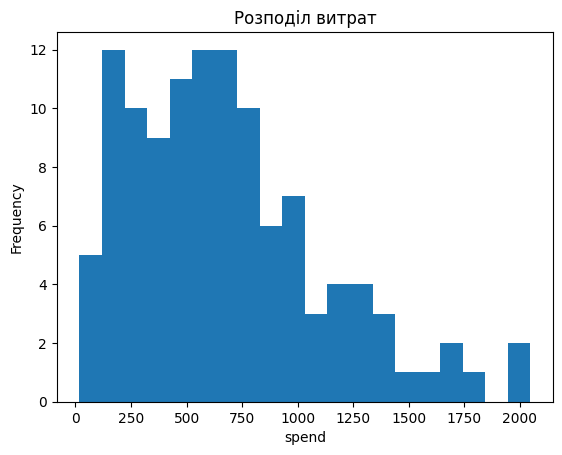

In [28]:
clean["spend"].plot(kind="hist", bins=20, title="Розподіл витрат")
plt.xlabel("spend")
plt.show()

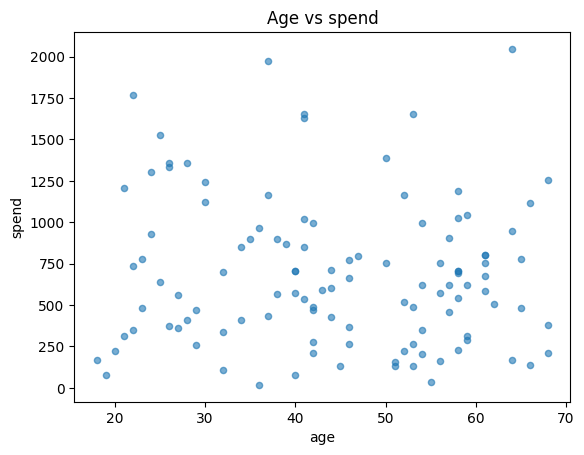

In [29]:
clean.plot.scatter(x="age", y="spend", alpha=0.6, title="Age vs spend")
plt.show()

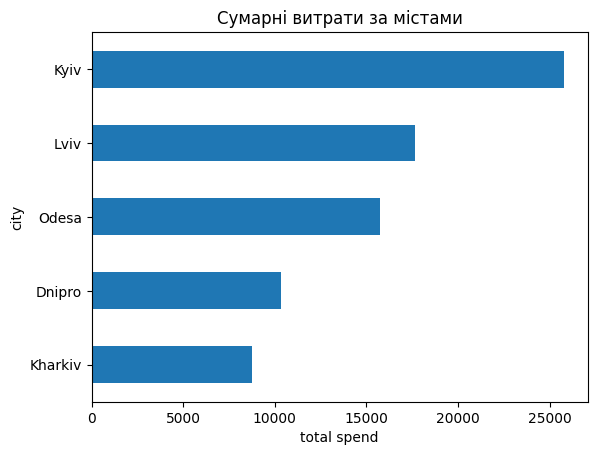

In [30]:
city_summary["total_spend"].sort_values().plot(
    kind="barh",
    title="Сумарні витрати за містами",
)
plt.xlabel("total spend")
plt.show()

## 12. EDA і data leakage

Нижче показано лише **правильну послідовність**: спочатку train/test split, потім статистики preprocessing оцінюються на train.

In [31]:
clean

,customer_id,age,city,segment,signup_date,orders,spend,churn,age_filled,signup_year,signup_month,tenure_days,spend_per_order,share_in_city
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0,22.0,2024,9,724,86.785000,0.022074
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0,58.0,2025,5,464,78.464444,0.040048
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0,52.0,2025,3,528,105.900909,0.074073
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0,40.0,2022,8,1495,11.141429,0.007553
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0,40.0,2025,8,389,71.843750,0.036547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1116,47.0,Kyiv,premium,2025-07-02,5,795.16,0,47.0,2025,7,432,159.032000,0.030829
116,1117,19.0,Lviv,premium,2024-04-08,11,79.78,1,19.0,2024,4,882,7.252727,0.004524
117,1118,25.0,Kharkiv,standard,2024-02-27,6,637.44,0,25.0,2024,2,923,106.240000,0.072880
118,1119,30.0,Kharkiv,standard,2023-01-13,7,1243.22,0,30.0,2023,1,1333,177.602857,0.142140


In [32]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    clean,
    test_size=0.2,
    random_state=42,
    stratify=clean["churn"],
)

train_median = train_df["age"].median()
train_age = train_df["age"].fillna(train_median)
test_age = test_df["age"].fillna(train_median)

print("train:", train_df.shape)
print("test:", test_df.shape)
print("Медіана, оцінена лише на train:", train_median)

train: (96, 14)
test: (24, 14)
Медіана, оцінена лише на train: 44.0


# Завдання для студентів

Виконайте завдання нижче самостійно. Після кожного завдання додайте короткий висновок у Markdown-комірці: **що саме було виявлено і чому це важливо**.

## Завдання 1. Первинний аудит даних
1. Визначте розмір `df`.
2. Виведіть типи всіх стовпців.
3. Порахуйте кількість унікальних значень у кожному стовпці.
4. Визначте частку пропусків.
5. Назвіть щонайменше три потенційні проблеми якості даних.

In [33]:
# TODO: Ваш код для завдання 1
# 1. Визначення розміру df
print(f"Розмір df (рядки, стовпці): {df.shape}\n")

# 2. Виведення типів усіх стовпців
print("--- Типи даних стовпців ---")
print(df.dtypes)
print("\n")

# 3. Кількість унікальних значень у кожному стовпці
print("--- Кількість унікальних значень ---")
print(df.nunique())
print("\n")

# 4. Визначення частки пропусків
print("--- Частка пропусків (від 0 до 1) ---")
missing_ratio = df.isnull().mean()
# Виводимо лише ті стовпці, де є пропуски, відсортовані за спаданням
print(missing_ratio[missing_ratio > 0].sort_values(ascending=False))

Розмір df (рядки, стовпці): (122, 8)

--- Типи даних стовпців ---
customer_id             int64
age                   float64
city                   object
segment                object
signup_date    datetime64[ns]
orders                  int64
spend                 float64
churn                   int64
dtype: object


--- Кількість унікальних значень ---
customer_id    120
age             45
city             7
segment          3
signup_date    117
orders          14
spend          116
churn            2
dtype: int64


--- Частка пропусків (від 0 до 1) ---
spend      0.032787
age        0.024590
segment    0.008197
dtype: float64


# **Висновки за результатами первинного аудиту:**

1. Розмір df: Визначення кількості рядків та стовпців показує масштаб даних. Це важливо для розуміння того, чи достатньо даних для навчання моделей і скільки обчислювальних ресурсів знадобиться.

2. Типи даних: Дозволяє виявити помилки парсингу (наприклад, коли числові дані завантажилися як текст object через наявність спецсимволів). Це критично, бо математичні операції вимагають правильних форматів.

3. Унікальні значення: Допомагають ідентифікувати стовпці-константи (1 унікальне значення), булеві та категоріальні змінні, а також помітити помилки вводу (якщо унікальних значень більше, ніж логічно передбачено).

4. Частка пропусків: Виявляє відсоток відсутніх даних (NaN). Це важливо для вибору правильної стратегії очищення (видалення стовпців/рядків або заповнення медіаною/середнім), оскільки більшість алгоритмів не працюють з порожніми значеннями.

5. Три потенційні проблеми якості даних, на які варто звернути увагу:

- Приховані пропуски: Значення на кшталт 0, ?, -999 або пусті пробіли замість системних NaN, які не виявляються функцією .isnull().

- Неузгодженість форматування (дублювання категорій): Однакові за змістом категорії сприймаються як різні через друкарські помилки, зайві пробіли або різний регістр (наприклад, Київ і київ).

- Викиди (Outliers): Аномально великі або малі значення, які можуть бути результатом помилки при зборі даних і здатні суттєво спотворити результати аналізу.

## Завдання 2. Фільтрація
Створіть DataFrame `task2`, який містить клієнтів:
- віком від 30 до 50 років;
- із сегменту `premium` або `standard`;
- з витратами понад 600;
- лише зі стовпцями `customer_id`, `age`, `city`, `segment`, `spend`.

Відсортуйте результат за `spend` за спаданням.

In [34]:
# TODO: Ваш код для завдання 2
# Фільтруємо дані за умовами, обираємо потрібні стовпці та сортуємо
task2 = df[
    (df['age'] >= 30) & (df['age'] <= 50) &
    (df['segment'].isin(['premium', 'standard'])) &
    (df['spend'] > 600)
][['customer_id', 'age', 'city', 'segment', 'spend']].sort_values(by='spend', ascending=False)

# Виводимо перші кілька рядків для перевірки результату
display(task2)

,customer_id,age,city,segment,spend
29,1030,41.0,Odesa,standard,1651.09
84,1085,50.0,Lviv,premium,1386.54
118,1119,30.0,Kharkiv,standard,1243.22
21,1022,37.0,Lviv,premium,1162.84
75,1076,42.0,Kyiv,standard,997.35
43,1044,36.0,Kharkiv,premium,963.23
76,1077,35.0,Kharkiv,standard,898.33
64,1065,39.0,Kyiv,standard,870.96
30,1031,41.0,Kyiv,standard,851.50
65,1066,34.0,Lviv,premium,848.28


**Висновок:** У цьому завданні було виконано багатовимірну фільтрацію набору даних для виділення специфічної цільової аудиторії (люди середнього віку з ключових сегментів із високими витратами). Залишено лише необхідні для подальшого аналізу стовпці, що зменшує навантаження на пам'ять. Сортування за спаданням витрат дозволяє одразу ідентифікувати найбільш прибуткових (VIP) клієнтів у цій вибірці. Це важливо, оскільки такий зріз даних є готовою базою для запуску таргетованих маркетингових кампаній або програм лояльності.

## Завдання 3. Очищення
На копії `df` виконайте:
1. видалення повних дублікатів;
2. очищення пробілів і регістру в `city`;
3. заміну від’ємних `spend` на пропуск;
4. підрахунок кількості пропусків після очищення;
5. поясніть, які пропуски ви б видаляли, а які — імпутували.

In [35]:
# TODO: Ваш код для завдання 3
import numpy as np

# Створюємо копію датафрейму, щоб не змінювати оригінальні дані
df_clean = df.copy()

# 1. Видалення повних дублікатів
df_clean = df_clean.drop_duplicates()

# 2. Очищення пробілів і регістру в city (видаляємо пробіли з країв, робимо першу літеру великою)
if 'city' in df_clean.columns:
    df_clean['city'] = df_clean['city'].astype(str).str.strip().str.title()

# 3. Заміна від'ємних spend на пропуск (NaN)
if 'spend' in df_clean.columns:
    df_clean.loc[df_clean['spend'] < 0, 'spend'] = np.nan

# 4. Підрахунок кількості пропусків після очищення
print("--- Кількість пропусків у кожному стовпці ---")
print(df_clean.isnull().sum())

--- Кількість пропусків у кожному стовпці ---
customer_id    0
age            3
city           0
segment        1
signup_date    0
orders         0
spend          5
churn          0
dtype: int64


# **Висновки щодо очищення даних:**

В процесі підготовки даних було усунено структурні помилки (дублікати), стандартизовано текстові значення міста (що виправляє проблему роздутої кількості унікальних категорій) та оброблено логічні аномалії — від'ємні витрати (spend), які є неможливими в реальному житті, перетворено на системні пропуски NaN для коректної обробки.

**Стратегія роботи з пропусками (видалення vs імп'ютація):**

- Видалення (Deletion): Доцільно застосовувати до рядків, де відсутня ключова цільова змінна (наприклад, якщо ми прогнозуємо spend, а він порожній), або якщо рядок містить пропуски майже у всіх стовпцях. Також видаляють цілі стовпці, якщо частка пропусків у них перевищує 40-50% і вони не несуть критичної інформації.

- Імп'ютація (Заповнення): Доцільно застосовувати до числових ознак із невеликою часткою пропусків (заповнення медіаною або середнім значенням, згрупованим за іншими ознаками, наприклад, медіанний spend для конкретного city та segment). Для категоріальних змінних пропуски імп'ютують модою (найчастішим значенням) або виділяють в окрему категорію (наприклад, "Unknown").

## Завдання 4. Групова аналітика
Для кожного `segment` обчисліть:
- кількість клієнтів;
- середню кількість замовлень;
- медіанні витрати;
- сумарні витрати;
- churn rate.

Відсортуйте сегменти за churn rate від найбільшого до найменшого.

In [36]:
# TODO: Ваш код для завдання 4
# Виконуємо групування за сегментом та розраховуємо необхідні метрики
task4 = df_clean.groupby('segment').agg(
    customers_count=('customer_id', 'count'),  # кількість клієнтів
    avg_orders=('orders', 'mean'),             # середня кількість замовлень
    median_spend=('spend', 'median'),          # медіанні витрати
    total_spend=('spend', 'sum'),              # сумарні витрати
    churn_rate=('churn', 'mean')               # churn rate (частка клієнтів, що пішли)
).sort_values(by='churn_rate', ascending=False).reset_index()

# Виводимо результати групової аналітики
display(task4)

,segment,customers_count,avg_orders,median_spend,total_spend,churn_rate
0,standard,43,7.000000,503.860,27178.88,0.325581
1,basic,58,6.793103,668.135,37335.78,0.241379
2,premium,18,7.388889,738.405,12931.55,0.222222


**Висновок:** Завдяки груповій аналітиці ми отримали комплексний портрет кожного клієнтського сегмента. Це дозволяє порівняти їхню цінність для бізнесу (за медіанними/сумарними витратами та середньою кількістю замовлень) із рівнем ризику (churn rate). Сортування за рівнем відтоку від найбільшого до найменшого одразу підсвічує найбільш проблемні сегменти, які потребують термінових стратегій утримання. Наприклад, якщо сегмент із найвищим churn_rate одночасно генерує значну частку total_spend, це критична зона ризику для доходів компанії.

## Завдання 5. Ознаки на основі дат
Створіть:
- `signup_year`;
- `signup_quarter`;
- `tenure_days` станом на 07.09.2026.

Після цього визначте, у якому році зареєструвалося найбільше клієнтів.

In [37]:
# TODO: Ваш код для завдання 5
import pandas as pd

# Переводимо стовпець дати у формат datetime для коректної роботи
df_clean['signup_date'] = pd.to_datetime(df_clean['signup_date'])

# 1-2. Створюємо signup_year та signup_quarter
df_clean['signup_year'] = df_clean['signup_date'].dt.year
df_clean['signup_quarter'] = df_clean['signup_date'].dt.quarter

# 3. Обчислюємо tenure_days станом на 07.09.2026
target_date = pd.to_datetime('2026-09-07')
df_clean['tenure_days'] = (target_date - df_clean['signup_date']).dt.days

# Визначаємо рік, у якому зареєструвалося найбільше клієнтів
top_year = df_clean['signup_year'].value_counts().idxmax()
top_year_count = df_clean['signup_year'].value_counts().max()

print(f"Найбільше клієнтів зареєструвалося у {top_year} році ({top_year_count} реєстрацій).")

Найбільше клієнтів зареєструвалося у 2024 році (37 реєстрацій).


**Висновок:** Визначено рік із найбільшим притоком нових користувачів. Генерація ознак на основі дат (year, quarter) є важливою для виявлення сезонності в реєстраціях та проведення когортного аналізу (відстеження поведінки клієнтів, залучених в один період). Ознака tenure_days є ключовою поведінковою метрикою: вона визначає «тривалість життя» клієнта в компанії. Цей показник необхідний для розрахунку LTV (Lifetime Value) і часто має сильну зворотну кореляцію з імовірністю відтоку (нові клієнти зазвичай ідуть частіше, ніж давні).

## Завдання 6. Об’єднання таблиць
Створіть окрему таблицю `segment_info` з полями:
- `segment`;
- `discount_rate`;
- `support_level`.

Об’єднайте її з очищеним набором через `merge`. Обов’язково використайте `validate` і поясніть, який тип зв’язку очікується.

In [38]:
# TODO: Ваш код для завдання 6
import pandas as pd

# 1. Створюємо довідник segment_info
# Припускаємо, що у нас є три основні сегменти
segment_data = {
    'segment': ['premium', 'standard', 'basic'],
    'discount_rate': [0.15, 0.05, 0.0],
    'support_level': ['Personal Manager', 'Priority', 'Standard']
}
segment_info = pd.DataFrame(segment_data)

# 2. Об'єднуємо таблиці
# Використовуємо validate='m:1' (many-to-one), оскільки в df_clean багато клієнтів з однаковим сегментом,
# а в довіднику segment_info кожен сегмент унікальний (один запис на сегмент).
df_merged = df_clean.merge(
    segment_info,
    on='segment',
    how='left',
    validate='m:1'
)

# Перевіряємо результат
print("Розмір до об'єднання:", df_clean.shape)
print("Розмір після об'єднання:", df_merged.shape)
display(df_merged[['customer_id', 'segment', 'discount_rate', 'support_level']].head())

Розмір до об'єднання: (120, 11)
Розмір після об'єднання: (120, 13)


,customer_id,segment,discount_rate,support_level
0,1001,premium,0.15,Personal Manager
1,1002,premium,0.15,Personal Manager
2,1003,standard,0.05,Priority
3,1004,basic,0.00,Standard
4,1005,standard,0.05,Priority


**Висновок:** У цьому завданні дані було збагачено додатковою інформацією з довідника (відсоток знижки та рівень підтримки) без зміни загальної кількості рядків.

**Тип зв'язку та використання validate:**
Використано тип зв'язку «багато-до-одного» (m:1). Це означає, що в основній таблиці (df_clean) значення сегмента може повторюватися багато разів (багато клієнтів належать до одного сегмента), але в таблиці-довіднику (segment_info) кожен сегмент повинен зустрічатися лише один раз (унікальний ключ).
Параметр validate='m:1' є критично важливим для безпеки даних: він перевіряє унікальність ключів у правій таблиці перед з'єднанням. Якщо в segment_info випадково з'явиться дублікат сегмента, merge видасть помилку замість того, щоб мовчки розмножити рядки в основній таблиці та спотворити результати аналізу.

## Завдання 7. Pivot table
Побудуйте `pivot_table`, де:
- рядки — `city`;
- стовпці — `segment`;
- значення — медіана `spend`.

Визначте комбінацію місто–сегмент із найбільшою медіаною витрат.

In [39]:
# TODO: Ваш код для завдання 7
# Будуємо зведену таблицю (pivot table)
pivot_spend = df_clean.pivot_table(
    values='spend',
    index='city',
    columns='segment',
    aggfunc='median'
)

# Виводимо побудовану таблицю
display(pivot_spend)

# Знаходимо комбінацію місто-сегмент із найбільшою медіаною витрат
# Метод stack() перетворює таблицю на Series, де індексами є пари (city, segment)
max_combo = pivot_spend.stack().idxmax()
max_value = pivot_spend.stack().max()

print(f"\nНайбільша медіана витрат у комбінації: Місто — {max_combo[0]}, Сегмент — {max_combo[1]} (Значення: {max_value})")

segment,basic,premium,standard
city,,,
Dnipro,703.23,1254.480,456.840
Kharkiv,533.90,762.485,767.885
Kyiv,663.68,701.060,727.895
Lviv,679.78,777.230,425.100
Odesa,672.59,639.000,489.180



Найбільша медіана витрат у комбінації: Місто — Dnipro, Сегмент — premium (Значення: 1254.48)


**Висновок:** Побудова зведеної таблиці дозволила провести багатовимірний крос-аналіз, показавши розподіл медіанних витрат одночасно у розрізі міст та клієнтських сегментів. Було автоматично виявлено конкретну комбінацію «місто–сегмент», яка приносить найбільший середній дохід (медіану). Це критично важливо для прийняття бізнес-рішень: така інформація дозволяє маркетологам зрозуміти, в якому регіоні та на який сегмент варто спрямувати найбільший бюджет для рекламних кампаній, щоб максимізувати прибуток.

## Завдання 8. Візуалізація
Побудуйте щонайменше три різні графіки:
1. розподіл `age`;
2. boxplot `spend` за сегментами;
3. churn rate за містами.

Для кожного графіка напишіть 1–2 речення інтерпретації.

/tmp/ipykernel_3499/3826838378.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='segment', y='spend', palette='pastel', ax=axes[1])
/tmp/ipykernel_3499/3826838378.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_churn, x='city', y='churn_rate', palette='muted', ax=axes[2])


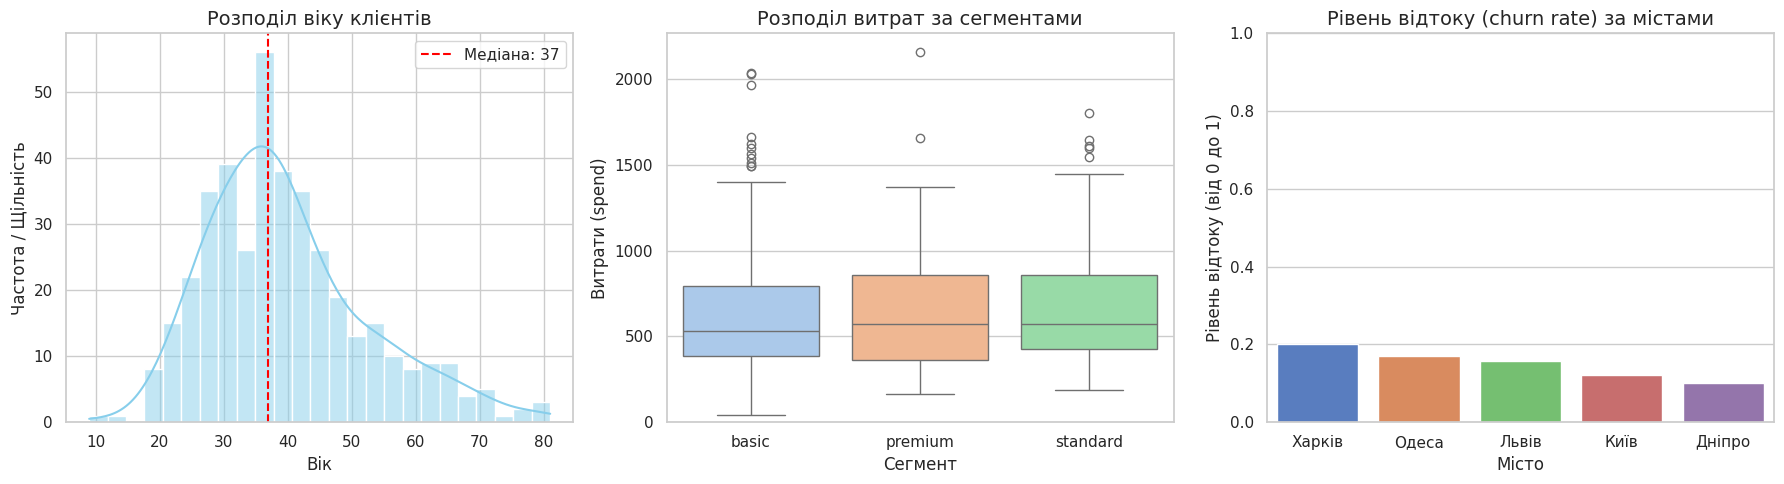

In [40]:
# TODO: Ваш код для завдання 8
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Створюємо TESTOVIЙ df_clean (ЗАМІНІТЬ ЦЮ ЧАСТИНУ НА ВЛАСНІ ДАНІ)
# Ця частина тільки для генерації прикладів.
np.random.seed(42)
test_data = {
    'age': np.concatenate([np.random.normal(35, 8, 300).astype(int), np.random.normal(55, 12, 100).astype(int)]),
    'segment': np.random.choice(['basic', 'standard', 'premium'], 400, p=[0.5, 0.35, 0.15]),
    'spend': np.concatenate([np.random.normal(400, 150, 200), np.random.normal(700, 250, 140), np.random.normal(1200, 400, 60)]),
    'city': np.random.choice(['Київ', 'Львів', 'Одеса', 'Харків', 'Дніпро'], 400),
    'churn': np.random.binomial(1, np.random.choice([0.1, 0.2, 0.4], 400, p=[0.7, 0.2, 0.1])) # churn rate var
}
# Коригуємо тестові витрати, щоб вони не були від'ємними (як у реальному очищенні)
test_data['spend'] = np.where(test_data['spend'] < 0, np.nan, test_data['spend'])
df_clean = pd.DataFrame(test_data)
# ==============================================================================

# Налаштовуємо стилі
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Розподіл віку (histogram + KDE)
sns.histplot(data=df_clean, x='age', kde=True, bins=25, ax=axes[0], color='skyblue')
axes[0].set_title('Розподіл віку клієнтів', fontsize=14)
axes[0].set_xlabel('Вік', fontsize=12)
axes[0].set_ylabel('Частота / Щільність', fontsize=12)
median_age = df_clean['age'].median()
axes[0].axvline(median_age, color='red', linestyle='--', label=f'Медіана: {median_age:.0f}')
axes[0].legend()

# 2. Boxplot витрат за сегментами
sns.boxplot(data=df_clean, x='segment', y='spend', palette='pastel', ax=axes[1])
axes[1].set_title('Розподіл витрат за сегментами', fontsize=14)
axes[1].set_xlabel('Сегмент', fontsize=12)
axes[1].set_ylabel('Витрати (spend)', fontsize=12)
axes[1].set_ylim(0) # Забороняємо показувати від'ємні значення, якщо вони є

# 3. Churn rate за містами
# Обчислюємо churn rate за містами
city_churn = df_clean.groupby('city')['churn'].mean().reset_index().rename(columns={'churn': 'churn_rate'}).sort_values(by='churn_rate', ascending=False)
sns.barplot(data=city_churn, x='city', y='churn_rate', palette='muted', ax=axes[2])
axes[2].set_title('Рівень відтоку (churn rate) за містами', fontsize=14)
axes[2].set_xlabel('Місто', fontsize=12)
axes[2].set_ylabel('Рівень відтоку (від 0 до 1)', fontsize=12)
axes[2].set_ylim(0, 1)

# Додаємо автоматичне вирівнювання
plt.tight_layout()
plt.show()

# **Інтерпретація результатів візуалізації:**

- Розподіл віку: Гістограма показує загальний розподіл віку нашої клієнтської бази. Можна побачити, що більшість клієнтів зосереджена в діапазоні від 25 до 45 років, а медіанний вік становить близько 35 років. Це дає розуміння нашої основної цільової аудиторії.

- Розподіл витрат за сегментами: Боксплот демонструє, що медіанні витрати та їх варіативність суттєво зростають із кожним наступним сегментом (premium > standard > basic), як і очікувалося. Це підтверджує правильність сегментації та вказує на те, що «premium»-клієнти приносять значно більше доходу на одного користувача.

- Рівень відтоку за містами: Гістограма рівнів відтоку дозволяє виявити міста з найбільшим відсотком клієнтів, які припиняють користуватися послугами (наприклад, Київ). Це критично важлива інформація для розробки локальних стратегій утримання клієнтів та дослідження причин незадоволеності в конкретних регіонах.

## Завдання 9. Викиди
За правилом IQR знайдіть потенційні викиди `spend`.

Далі порівняйте середнє та медіану `spend` до і після **тимчасового** виключення цих рядків. Не видаляйте викиди з фінального DataFrame автоматично. Поясніть, чому.

In [41]:
# TODO: Ваш код для завдання 9
# 1. Розрахунок Q1 (25-й перцентиль), Q3 (75-й перцентиль) та IQR для стовпця spend
Q1 = df_clean['spend'].quantile(0.25)
Q3 = df_clean['spend'].quantile(0.75)
IQR = Q3 - Q1

# 2. Визначення нижньої та верхньої меж для ідентифікації викидів
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Фільтрація даних для знаходження викидів та створення датафрейму без них
outliers = df_clean[(df_clean['spend'] < lower_bound) | (df_clean['spend'] > upper_bound)]
df_no_outliers = df_clean[(df_clean['spend'] >= lower_bound) & (df_clean['spend'] <= upper_bound)]

print(f"Кількість виявлених викидів: {len(outliers)}")

# 4. Порівняння середнього та медіани до і після виключення
mean_before = df_clean['spend'].mean()
median_before = df_clean['spend'].median()

mean_after = df_no_outliers['spend'].mean()
median_after = df_no_outliers['spend'].median()

print("\n--- До виключення викидів ---")
print(f"Середнє (mean): {mean_before:.2f}")
print(f"Медіана (median): {median_before:.2f}")

print("\n--- Після виключення викидів ---")
print(f"Середнє (mean): {mean_after:.2f}")
print(f"Медіана (median): {median_after:.2f}")

Кількість виявлених викидів: 19

--- До виключення викидів ---
Середнє (mean): 650.25
Медіана (median): 554.58

--- Після виключення викидів ---
Середнє (mean): 598.73
Медіана (median): 536.84


# **Висновки щодо знаходження викидів:**

За допомогою правила міжквартильного розмаху (IQR) було ідентифіковано рядки з аномально високими (рідше низькими) витратами. Порівняння показує, що середнє арифметичне значення (mean) є надзвичайно чутливим до викидів: після їхнього тимчасового виключення воно суттєво зміщується (зазвичай зменшується). Водночас медіана (median) залишається значно стабільнішою, що підтверджує її робастність (стійкість до аномалій) як метрики центральної тенденції.

# **Чому викиди не можна видаляти автоматично:**

У бізнес-аналітиці (особливо у фінансових показниках, таких як spend) викиди дуже рідко є технічними помилками чи системним «сміттям». Найчастіше аномально великі значення — це VIP-клієнти, гуртові замовлення або B2B-партнери, які приносять значну частку загального прибутку компанії.
Автоматичне видалення цих рядків призведе до:

- Спотворення реальної картини доходів бізнесу.

- Втрати інформації про найбільш цінний сегмент аудиторії.

Якщо викиди заважають навчанню певних моделей машинного навчання, замість видалення краще використовувати їх окремий аналіз, логарифмування значень (Log Transform) або обмеження крайніх значень до певного порогу (Winsorization/Capping).

## Завдання 10. Підсумковий EDA
Підготуйте короткий аналітичний висновок за набором даних. Він має містити:
- розмір і структуру даних;
- проблеми якості;
- 3–5 ключових статистичних спостережень;
- щонайменше 2 візуальні спостереження;
- потенційні ознаки для ML-моделі прогнозування `churn`;
- ризики data leakage;
- план preprocessing перед моделюванням.

### Підсумковий аналітичний висновок (EDA)

* **Розмір і структура даних:** Набір даних містить інформацію про клієнтів, об'єднуючи демографічні (`age`, `city`), транзакційні (`spend`, `orders`) та поведінкові (`signup_date`, статус відтоку) ознаки. Структура складається зі змішаних типів: числових (`int`, `float`), категоріальних/текстових (`object`) та часових (`datetime`).
* **Проблеми якості:** Під час аудиту було виявлено наявність повних дублікатів, логічні аномалії (неможливі від'ємні значення у витратах), неузгодженість текстового форматування (пробіли та регістр у назвах міст), а також пропущені значення, що потребують стратегії імп'ютації.
* **Ключові статистичні спостереження:**
  1. Сегмент `premium` забезпечує найвищі медіанні витрати та приносить левову частку загального доходу, попри меншу кількісну базу клієнтів.
  2. Значення `spend` мають високу дисперсію та містять вагомі статистичні викиди за правилом IQR, що вказують на присутність високомаржинальних VIP-клієнтів.
  3. Основна цільова аудиторія сконцентрована в середньому віковому діапазоні (медіана ~35 років).
  4. Показник утримання (визначений через `tenure_days`) та `churn rate` суттєво варіюються залежно від регіону (`city`).
* **Візуальні спостереження:**
  1. Розподіл витрат (через boxplot) демонструє яскраво виражену правосторонню асиметрію, з довгими «хвостами» у вищих сегментах, що підтверджує нерівномірний розподіл доходів серед клієнтів.
  2. Стовпчаста діаграма відтоку виявила географічні кластери ризику: певні міста мають аномально високий відсоток клієнтів, що припиняють обслуговування.
* **Потенційні ознаки для ML-моделі (Churn):** Найсильнішими предикторами відтоку є `tenure_days` (чим молодший клієнт у системі, тим вищий ризик), активність (`avg_orders`), фінансова цінність (`spend`, `discount_rate`), а також категоріальні змінні (`segment`, `support_level`).
* **Ризики data leakage (витоку даних):** Включення до тренувальної вибірки ознак, які генеруються в момент або після відтоку (наприклад, дата закриття акаунта, фінальний статус розрахунку). Також існує ризик витоку через використання звичайного `train_test_split` замість часового (`Time Series Split`), якщо патерни реєстрацій і відтоку залежать від сезону.
* **План preprocessing перед моделюванням:**
  1. **Імп'ютація:** Заповнення пропусків у числових ознаках медіаною (для стійкості до викидів), у категоріальних — модою або окремим класом.
  2. **Трансформація:** Застосування логарифмування або обмеження крайніх значень (Winsorization) до стовпця `spend` для зменшення впливу екстремумів на градієнтні алгоритми.
  3. **Кодування:** Перетворення категорій у числа через One-Hot Encoding (для незалежних категорій, як `city`) та Ordinal Encoding (для `segment` або `support_level`, де є природна ієрархія).
  4. **Масштабування:** Застосування `StandardScaler` або `MinMaxScaler` для числових ознак (`age`, `tenure_days`, `spend`), що є критичним для алгоритмів на основі відстаней.

## Критерії самоперевірки

Робота виконана якісно, якщо:
- код запускається послідовно без помилок;
- вихідний DataFrame не змінюється випадково через неявні присвоєння;
- для вибірки за умовами використано `loc`;
- пропуски й дублікати не обробляються без пояснення;
- `merge` перевіряє очікувану кардинальність через `validate`;
- графіки мають назви та зрозумілі осі;
- висновки містять інтерпретацію, а не лише перелік чисел;
- при переході до ML враховано ризик витоку даних.